# This note book is testing preprocessing on the /original_resolution_parquet/df_P_tst.parquet & df_P_trn.parquet


This is slightly processed but this proof opf concept works 

In [1]:
import sys

import numpy as np
import keras
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from tqdm import tqdm

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

2026-05-27 12:13:53.846903: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-27 12:13:53.901622: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-27 12:13:56.082227: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
sys.path.insert(0, "/lustre/lrspec/users/4301/ABC-SN/code")
from data_degrading import degrade_spectrum
import abcsn_training
import abcsn_config
import data_preparation as dp
import preprocessing as pp


sys.path.insert(0, "/lustre/lrspec/users/4301/Milligan_project")
from process_data import *
from plot_data import *


sys.path.insert(0, "/lustre/lrspec/users/4301/snidpy/sourcepy")
from apodize import *
from logwave import Logwave as lw 
from logwave import log_rebin

# Classifying Supernova Spectra With ABC-SN

# 1. Load ABC-SN

The file `ABCSN.keras` is not hosted on GitHub because it is too large of a file. You must download it from Zenodo [here](https://zenodo.org/records/16620817). Place it in `abcsn/` and ensure that it is called `ABCSN.keras`. `ABCSN.keras` has been added to `.gitignore`.

In [3]:
abcsn = keras.models.load_model("/lustre/lrspec/users/4301/ABC-SN/abcsn/ABCSN.keras", compile=False)


2026-05-27 12:13:58.541733: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# 2. Data

Importing the data from Milligan et al.


df = orginal unedited data I have been processing 

test_df =  data from the resolution_100_parquet


In [4]:
df_trn = pd.read_parquet("/lustre/lrspec/users/4301/ABC-SN/data/original_resolution_parquet/df_P_trn.parquet")
df_tst = pd.read_parquet("/lustre/lrspec/users/4301/ABC-SN/data/original_resolution_parquet/df_P_tst.parquet")

df = pd.concat([df_trn, df_tst], ignore_index = True)
df = df.drop(['Exclude', 'Training Set'], axis = 1)

# from abc-sn preprocessing 
phase_range=(-20, 50)
ptp_range=(0.1, 100)
wvl_range=(4500, 7000)
df = pp.preproccess_dataframe(df, phase_range, ptp_range, wvl_range)


In [5]:
df.head()

,SN Subtype,SN Subtype ID,SN Maintype,SN Maintype ID,Spectral Phase,2501.69,2505.08,2508.48,2511.87,2515.28,...,9872.21,9885.59,9898.98,9912.39,9925.82,9939.27,9952.73,9966.21,9979.71,9993.24
0,IIL,14,II,3,9.9,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,IIL,14,II,3,10.9,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,IIL,14,II,3,12.9,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,IIL,14,II,3,42.8,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,IIP,13,II,3,-7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
Ia_index = df["SN Subtype"] =="Ia-norm"
phase_index = df["Spectral Phase"] == -8.5

df[phase_index & Ia_index]

,SN Subtype,SN Subtype ID,SN Maintype,SN Maintype ID,Spectral Phase,2501.69,2505.08,2508.48,2511.87,2515.28,...,9872.21,9885.59,9898.98,9912.39,9925.82,9939.27,9952.73,9966.21,9979.71,9993.24
496,Ia-norm,0,Ia,0,-8.5,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1018,Ia-norm,0,Ia,0,-8.5,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2599,Ia-norm,0,Ia,0,-8.5,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2894,Ia-norm,0,Ia,0,-8.5,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2970,Ia-norm,0,Ia,0,-8.5,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Text(0.5, 1.0, 'orginal data unprocessed')

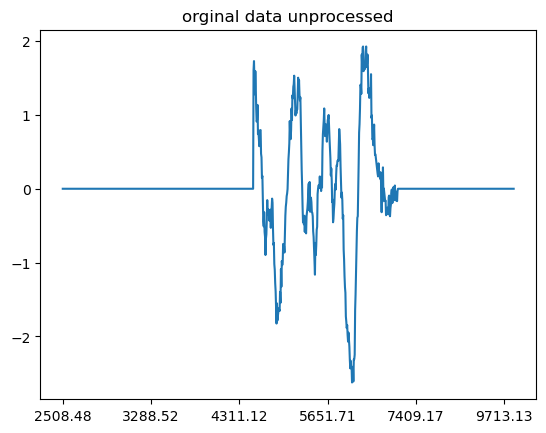

In [39]:
# "sn2008ar" = 496 
df.loc[496].iloc[7:].T.plot()
plt.title("orginal data unprocessed")

Text(0.5, 1.0, 'resolution_100_parquet data ')

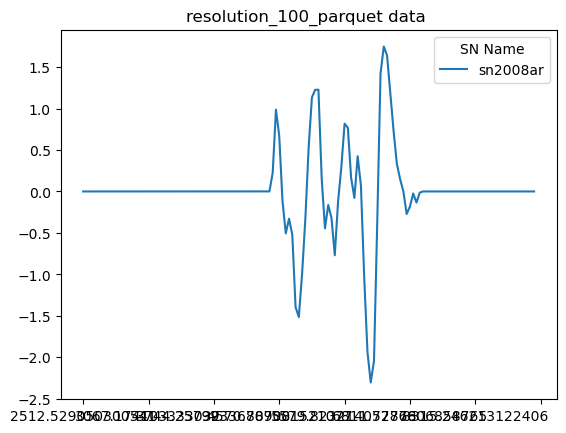

In [34]:
df_test = pd.read_parquet("/lustre/lrspec/users/4301/ABC-SN/data/resolution_100_parquet/df_SPAR_trn.parquet")
df_test.loc["sn2008ar"].iloc[:1,7:].T.plot() # sn1999gi
plt.title("resolution_100_parquet data ")

In [49]:
df_test.head()

,Exclude,SN Maintype,SN Maintype ID,SN Subtype,SN Subtype ID,Spectral Phase,Training Set,2512.529050300541,2537.7127325827696,2563.1488369626522,...,9096.145837554206,9187.318692546025,9279.405394966827,9372.415104528947,9466.357072754703,9561.240643896645,9657.075255867012,9753.870441176497,9851.635827882466,9950.38114054659
SN Name,,,,,,,,,,,,,,,,,,,,,
sn1979C,False,II,3,IIL,14,9.9,True,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sn1979C,False,II,3,IIL,14,10.9,True,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sn1979C,False,II,3,IIL,14,12.9,True,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sn1979C,False,II,3,IIL,14,42.8,True,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sn1979C,False,II,3,IIL,14,9.9,True,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [50]:
Xtrn, Ytrn, num_trn, num_wvl, num_classes, sn_dict_trn, wvl_original = dp.extract(df, return_wvl=True)

In [51]:
df[0:1].iloc[:,7:]

,2508.48,2511.87,2515.28,2518.69,2522.1,2525.51,2528.94,2532.36,2535.79,2539.23,...,9872.21,9885.59,9898.98,9912.39,9925.82,9939.27,9952.73,9966.21,9979.71,9993.24
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


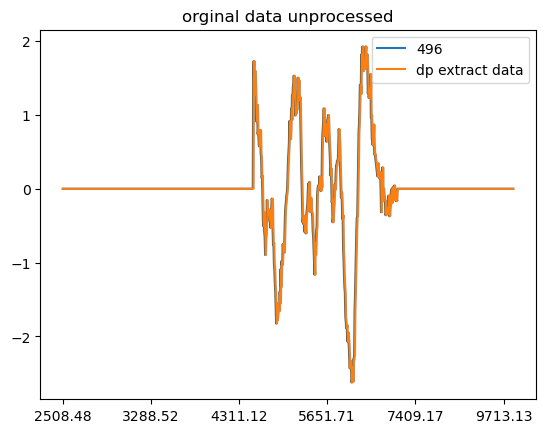

In [52]:
df.loc[496 ].iloc[7:].T.plot()
plt.title("orginal data unprocessed")
plt.plot(Xtrn[496], label = "dp extract data")
plt.legend()

## Extracting information from the file name:
[Host Morphology][True SN Class]Smag[SN Fibre Mag.]Gmag[Host Fibre Mag.]z[Redshift]texp[Exposure Time in Mins].txt

In [53]:
host_types = ["elliptical", "s0", "sa", "sb", "sc", "starb1", "starb1", "starb2", "starb3", "starb4", "starb5", "starb6"]
# needs to go longest to shortest so it doesnt find II instead of IIb
# there's Iap?? not mentioned in paper

sn_class_dict = {"IIb": "IIb",
                 "IIn": "IIn",
                 "II_": "II",
                 "Iap": "Iap",
                 "Ia_": "Ia",
                 "Ic_": "Ic",
                 "Ib_": "Ib",
                 "SL_": "SL",
                 "TDE": "TDE",
                 "CRT": "CaRT"}

In [54]:
df_metadata = pd.DataFrame()
df_metadata["sn_type"] = list(df["SN Maintype"])


In [55]:
df_metadata.sn_type.unique()

array(['II', 'Ib', 'Ia', 'Ic'], dtype=object)

## processing data

Each spectrum contains five columns, wavelength (0), flux (1), flux error (2), flux with no sky subtraction (3), flux error with no sky subtraction (4).

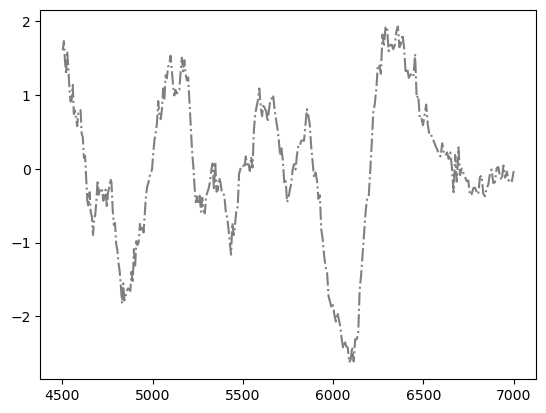

READ IN OK


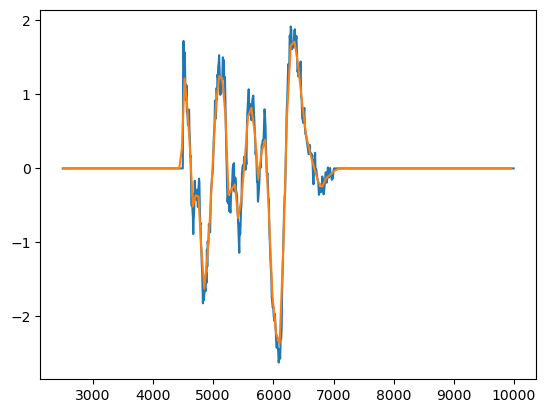

In [56]:
# test run
wvl, X = process_data(Xtrn[496], wvl_original, 4500, 7000, plot_spectra = True,
                    snidify = False, R =100)

In [57]:
test_wl = np.array(df_test.loc["sn2008ar"].iloc[:1,7:].columns)
test_wl = np.float64(test_wl)
sum(test_wl != wvl)

np.int64(0)

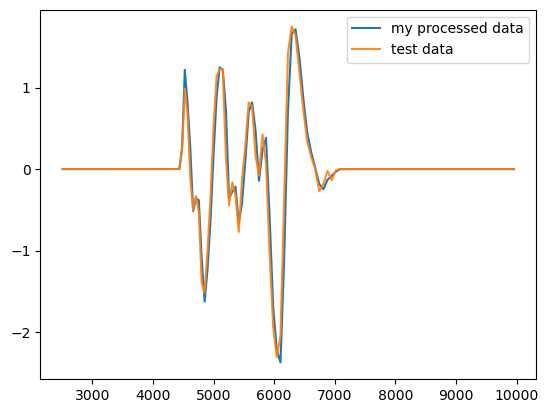

In [58]:

plt.plot(wvl.T, X[0], label = "my processed data")
plt.plot(test_wl, df_test.loc["sn2008ar"].iloc[:1,7:].T["sn2008ar"].values, 
         label= "test data", alpha = 0.9)
plt.legend()
# plt.xlim(4400, 4600)

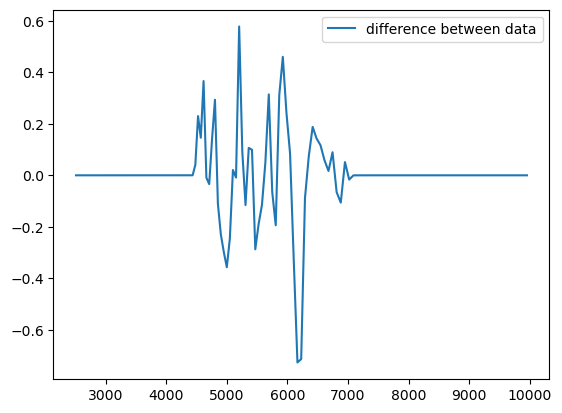

In [59]:
plt.plot(wvl.T, X[0]-df_test.loc["sn2008ar"].iloc[:1,7:].T["sn2008ar"].values, label = "difference between data")
plt.legend()
# plt.xlim(4400, 4600)

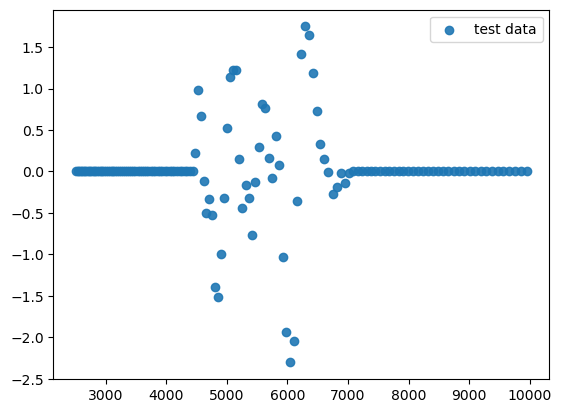

In [20]:


plt.scatter(wvl.T, df_test.loc["sn2008ar"].iloc[:1,7:].T["sn2008ar"].values, 
         label= "test data", alpha = 0.9)
plt.legend()


In [21]:
# used:
# abcsn_config.SN_Stypes_int_to_str replaced with ABC_subtype_id_to_str
# to make the dictionary corresponding to the labels used above
# may just want to change the above to use the same strings as int_to_str function
ABC_subtype_id_to_str = {
    0: "Ia-norm",
    1: "Ia-91T",
    2: "Ia-91bg",
    3: "Iax",
    4: "Ib-norm",
    5: "Ibn",
    6: "IIb",
    7: "Ic-norm",
    8: "Ic-broad",
    9: "IIP",
}

subtype_to_ABC_ID= {
     'Ia-norm': 0,
     'Ia-91T': 1,
     'Ia-csm': None,
     'Ia-91bg': 2,
     'Ib-norm':4,
     'Iax':3,
     'Ia-pec': None,
     'Ic-norm':7,
     'IIP':9,
     'IIL': None,
     'IIb':6,
     'II-pec': None, ### ?
     'Ic-broad':8,
     'Ic-pec': None,
     'IIn': None,
     'Ibn': 5,
     'Ib-pec': None,
}



ABC_ID_dict ={"Ia": 0,
          "Iap": 0,
          "Ic": 7,
          "Ib": 4,
          "II": 9, # IIP = type 2 plateau = normal
          "IIb": 6,
          "IIn": 9,
          "SL": None,
          "TDE": None,
          "CRT": None
          }

Mill_ID_dict ={"Ia": 0,
          "Iap": 0,
          "Ic": 1,
          "Ib": 1,
          "II": 2, # IIP = type 2 plateau = normal
          "IIb": 1,
          "IIn": 2,
          "SL": 3,
          "TDE": 4,
          "CRT": 4
          }

# five types recorded in Milligan et al.
Mill_types_to_int = {0: "Ia",
                     1: "Ib & Ic",
                     2: "II",
                     3: "SLSN",
                     4: "Non-SN",
                     5: "other"
                     }

# convert ABC types to Mill categories
ABC_to_Mill ={0:0,   # Ia-norm -> Ia
              1:0,   # Ia-91T -> Ia
              2:0,   # Ia-91bg -> Ia
              3:0,   # Iax -> Ia
              4:1,   # Ib-norm -> Ib & Ic
              5:1,   # Ibn -> Ib & Ic
              6:1,   # IIb -> Ib & Ic
              7:1,  # Ic-norm -> Ib & Ic
              8:1,  # Ic-broad -> Ib & Ic
              9:2,  # IIP -> II
            }


In [22]:
num_wvl = 139
dat_size = len(df_metadata)
plots = False

X_all = np.zeros((dat_size, 1, num_wvl))
Y_ABC_IDs = np.zeros((dat_size)) # classification as the float classifier
Y_Mill_IDs = np.zeros((dat_size)) # classification as the float classifier

for i in tqdm(range(dat_size)):
  wvl, X = process_data(Xtrn[i], wvl_original, 4500, 7000, plot_spectra = plots, verbose=False, snidify = False)
  X_all[i] = X
  # dont save wvl as all are the same

  try:
    Y_ABC_IDs[i] = subtype_to_ABC_ID[df["SN Subtype"][i]]
    Y_Mill_IDs[i] = Mill_ID_dict[df_metadata.sn_type[i]]

  except Exception as e:
    print(df_metadata.sn_type[i], i)
    raise e


df_metadata["ABC_ID"] = Y_ABC_IDs
df_metadata["Mill_ID"] = Y_Mill_IDs

index = ~np.isnan(Y_ABC_IDs)
df_metadata = df_metadata[index].reset_index()




  0%|          | 2/3966 [00:00<04:40, 14.14it/s]/home/4301/miniconda3/envs/abc-env/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
  3%|▎         | 100/3966 [00:06<04:22, 14.74it/s]

MEANZERO: This spectrum is zero!


  3%|▎         | 104/3966 [00:07<04:18, 14.94it/s]

MEANZERO: This spectrum is zero!
MEANZERO: This spectrum is zero!


  3%|▎         | 106/3966 [00:07<04:14, 15.17it/s]

MEANZERO: This spectrum is zero!


100%|██████████| 3966/3966 [04:31<00:00, 14.60it/s]


In [23]:
X_all.shape

(3966, 1, 139)

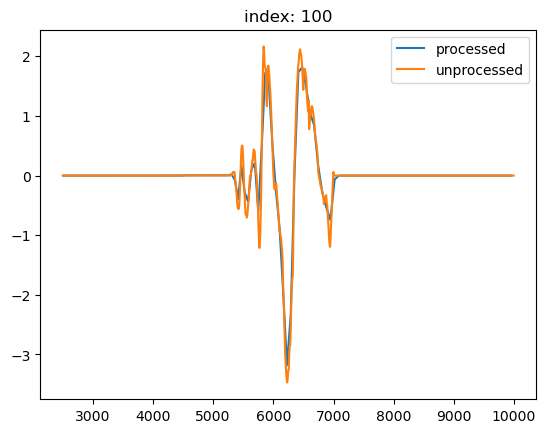

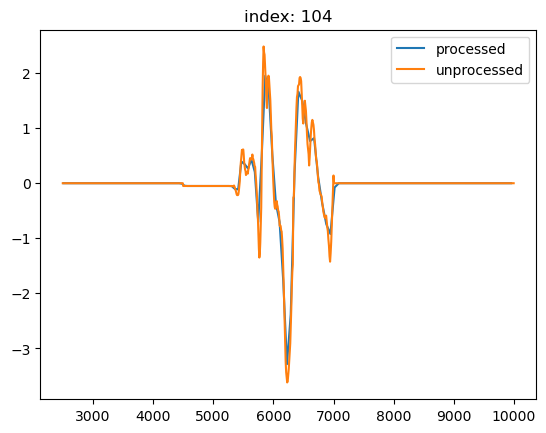

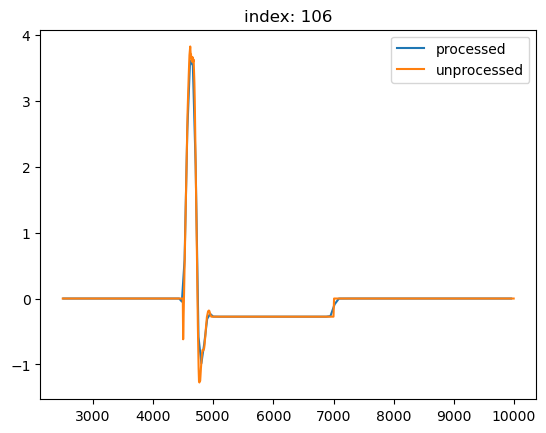

In [24]:
# meanzero error (using tqdm may need to -1 from index
meanzero_index = [100, 104, 106]
for i in meanzero_index:
    plt.plot(wvl.T, X_all[i-1][0], label = "processed")
    plt.plot(wvl_original, Xtrn[i-1], label = "unprocessed")
    plt.legend()
    plt.title(f"index: {i}")
    plt.show()


# 3. Predict

1. `X` is your array of spectra to classify.
2. `P` is your array of output probabilities of each of the 10 classes.
3. `P_argmax` is your array of final predictions for each spectra in `X`. Class IDs defined from 0-10.
4. `P_IDs` is your array of final predictions for each spectra in `X`. Class IDs defined from 0-16.
5. `P_str` is the final SN subtype prediction for each spectra in `X`.

In [25]:
X = X_all.copy()
X = X[index]
P = abcsn.predict(X, verbose=0)
P_argmax = np.argmax(P, axis=1)

2026-05-27 12:18:32.890688: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [26]:
cr = (classification_report(
    df_metadata["ABC_ID"],
    P_argmax,
    labels=list(ABC_subtype_id_to_str.keys()),
    target_names=list(ABC_subtype_id_to_str.values())
    ))

print(cr)

              precision    recall  f1-score   support

     Ia-norm       0.97      0.88      0.92      2114
      Ia-91T       0.64      0.90      0.75       348
     Ia-91bg       0.81      0.89      0.85       232
         Iax       0.90      1.00      0.95        62
     Ib-norm       0.89      0.85      0.87       211
         Ibn       0.90      1.00      0.95        27
         IIb       0.90      0.89      0.89       232
     Ic-norm       0.72      0.93      0.81       206
    Ic-broad       0.99      0.87      0.93       228
         IIP       0.98      0.98      0.98       104

    accuracy                           0.89      3764
   macro avg       0.87      0.92      0.89      3764
weighted avg       0.91      0.89      0.89      3764



/lustre/lrspec/users/4301/Milligan_ABC-SN/plot_data.py:12: RuntimeWarning: invalid value encountered in divide
  cm = cm.astype("float") / np.nansum(cm, axis=1)[:, np.newaxis]


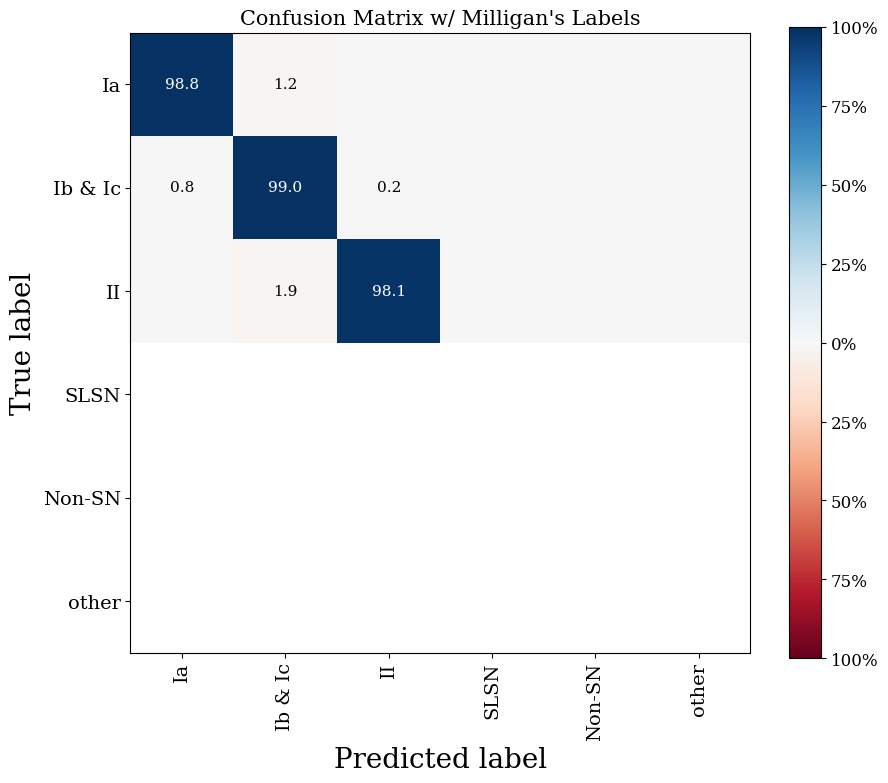

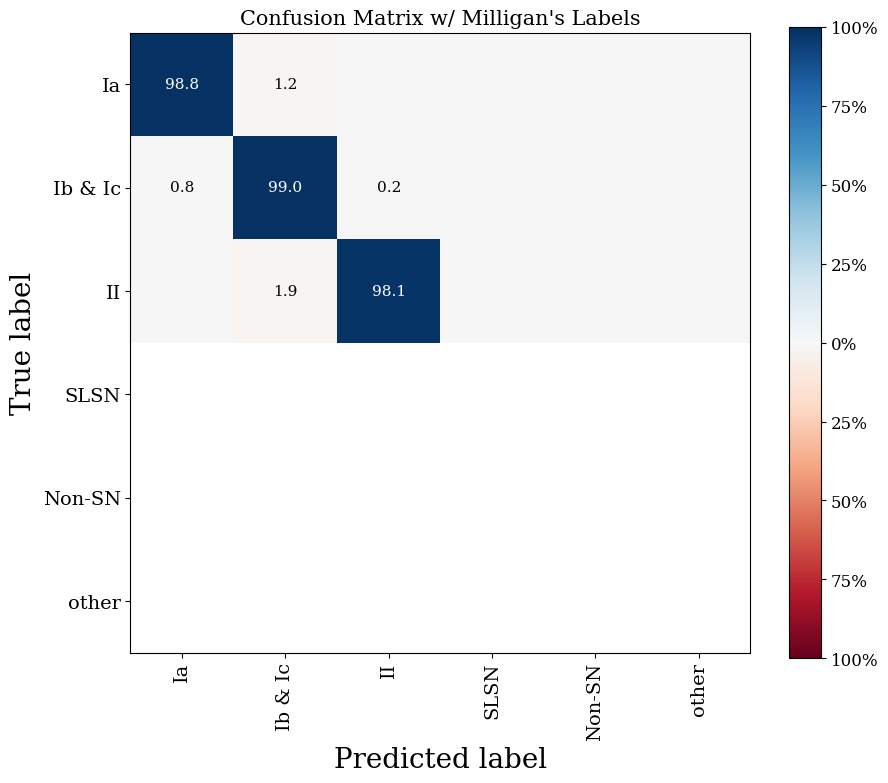

In [27]:
from sklearn.metrics import confusion_matrix

# confusion matrix using Mill. categories

P_Mill = np.array([ABC_to_Mill[i] for i in P_argmax])

cm = confusion_matrix(df_metadata["Mill_ID"], P_Mill, labels=list(Mill_types_to_int.keys()))

plot_cm(cm, list(Mill_types_to_int.values()), title = "Confusion Matrix w/ Milligan's Labels")

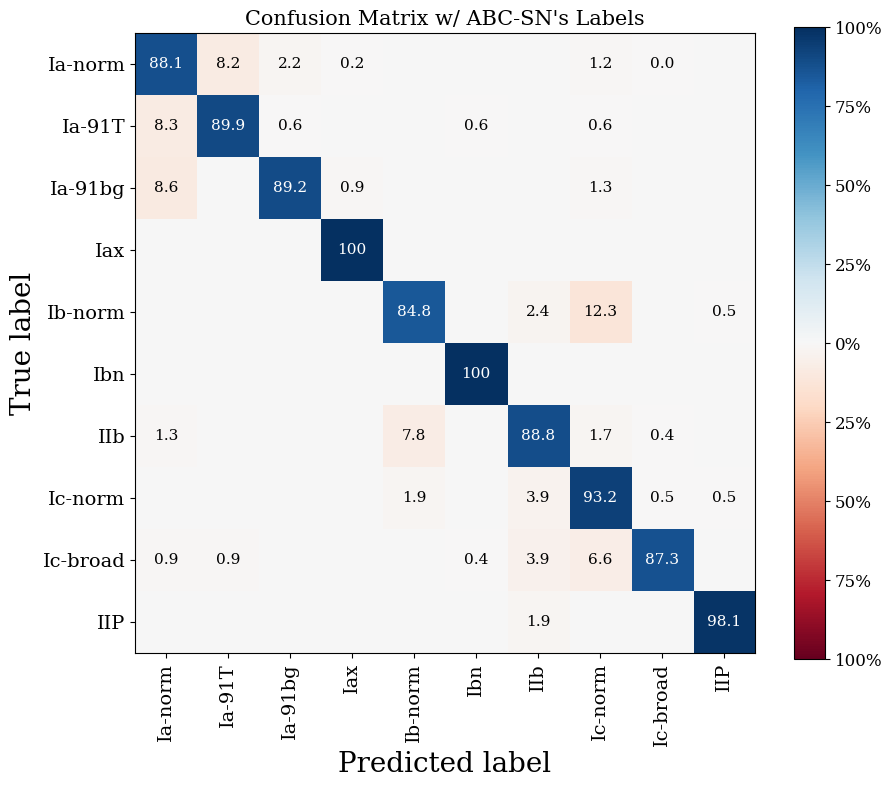

In [28]:
cm_abc = confusion_matrix(df_metadata["ABC_ID"],  P_argmax) #, 
                           #labels=list(ABC_subtype_id_to_str.values()))
plot = plot_cm(cm_abc, list(ABC_subtype_id_to_str.values()), title = "Confusion Matrix w/ ABC-SN's Labels")

/tmp/ipykernel_11426/4135016776.py:20: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "g", label="Average")


Text(0.5, 0.98, 'test normalization')

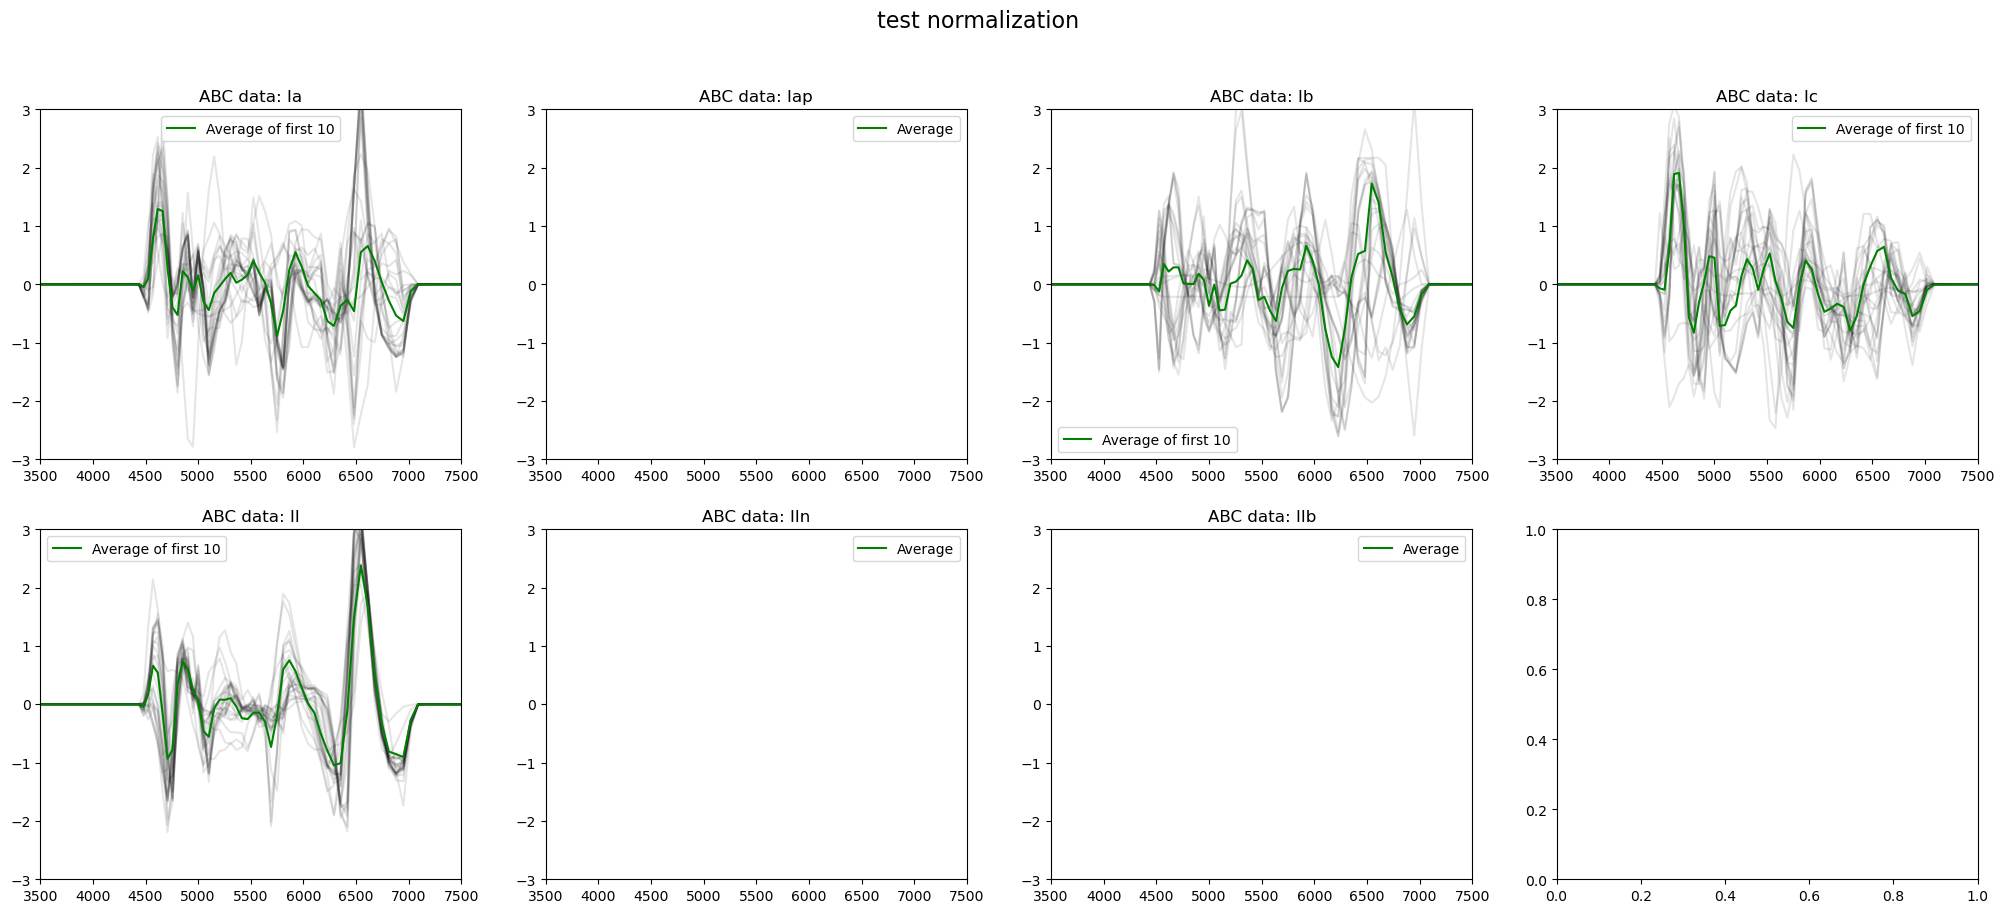

In [29]:
types = ['Ia', 'Iap', 'Ib',   'Ic', 'II', 'IIn', 'IIb']
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(25, 10)) # Adjust figsize as needed
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration


for j, sn_type in enumerate(types):
    ax = axes[j]
    temp_df = df_metadata[df_metadata.sn_type == sn_type]
    
    dat_size = len(temp_df)
    X_temp = np.zeros((num_wvl, ))

    for n, i in enumerate(temp_df.index.values):
        if n < 10:
            X_temp += X_all[i][0]
        if n < 25:
            ax.plot(wvl, X_all[i][0], alpha = 0.1, color = "k")

    if dat_size < 10:
        ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "g", label="Average")
    else:
        ax.plot(wvl, X_temp/10 , alpha = 1, color = "g", label="Average of first 10")
    ax.set_title(f"ABC data: {sn_type}")
    ax.set_ylim(-3, 3)
    ax.set_xlim(3500,7500)
    ax.legend()

fig.suptitle("test normalization", fontsize =16)

<Axes: >

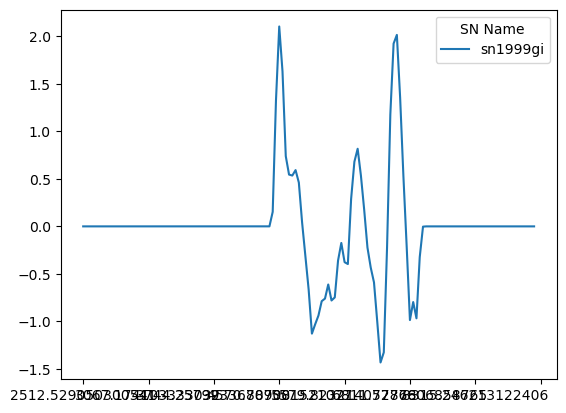

In [30]:
df_test = pd.read_parquet("/lustre/lrspec/users/4301/ABC-SN/data/resolution_100_parquet/df_SPAR_trn.parquet")
df_test[0:1].iloc[:,7:].T.plot() # sn1999gi

<Axes: >

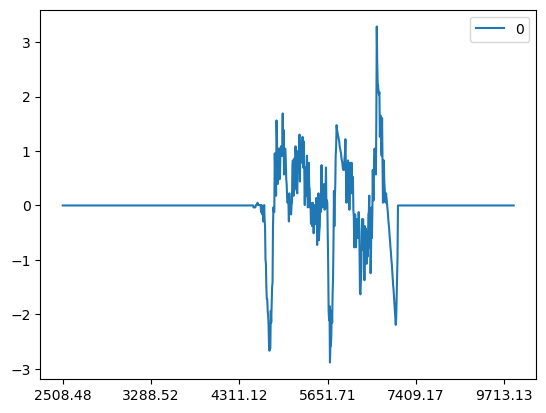

In [31]:
df[0:1].iloc[:,7:].T.plot() # sn1999gi

In [32]:
df[:1][7:].T

""
SN Subtype
SN Subtype ID
SN Maintype
SN Maintype ID
Spectral Phase
...
9939.27
9952.73
9966.21
9979.71
